# Задание: Сверточная нейронная сеть для распознавания рукописных цифр (MNIST)

**Параметры модели:** минимум 2 сверточных слоя; полносвязные слои; слои подвыборки, нормализации, регуляризации по 1 шт.

**Гиперпараметры обучения:** функция ошибки - категориальная кроссэнтропия, оптимизатор - Adam с шагом обучения одна тысячная, размер батча - 128, количество эпох 15, детали обучения - отображаются.

In [1]:
# загрузка датасета MNIST
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# Подключение утилит для to_categorical
from tensorflow.keras import utils

# Подключение библиотеки для работы с массивами
import numpy as np

# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt

# Подключение библиотеки для генерации случайных чисел
import random

# Подключение класса для работы с изображением
from PIL import Image

# Вывод изображений в ноутбуке, а не в консоли или файле
%matplotlib inline

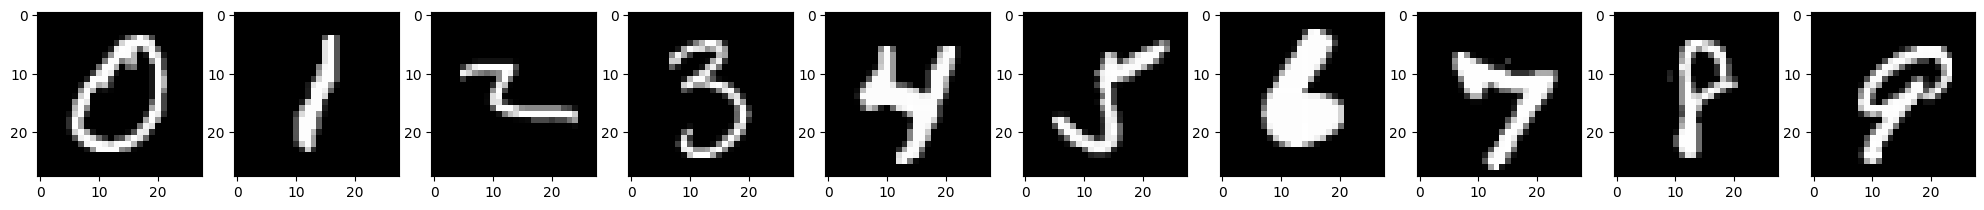

In [3]:
# вывод изображений каждого класса для ознакомления с датасетом
fig, axs = plt.subplots(1, 10, figsize=(25,3)) # создаем полотно для 10 графиков с размером 25 на 3
for i in range(10):
    label_indexes = np.where(y_train == i)[0] # получаем список из индексов положений класса i в y_train
    index = random.choice(label_indexes) # выбирает случайный индекс из списка созданного выше
    img = x_train[index] # выбираем из x_train нужное положение
    axs[i].imshow(Image.fromarray(img), cmap='gray') # выводим изображение

plt.show()

In [4]:
# добавляем размерность массиву mnist, чтобы сеть поняла что это ЧБ
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

# преобразуем выборки с ответами в OHE
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

# посмотрим форматы выборок перед обучением
print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print()
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)

y_train: (60000, 10)
y_test: (10000, 10)


# Ваше решение

In [5]:
# Подключение необходимых слоев
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, Rescaling
from tensorflow.keras.optimizers import Adam

# Создание модели
model = Sequential()

# ========== Слой нормализации входных данных ==========
# Rescaling приводит значения пикселей из диапазона [0, 255] в [0, 1]
model.add(Rescaling(1./255, input_shape=(28, 28, 1)))

# ========== Первый сверточный блок ==========
# Сверточный слой 1: 32 фильтра 3x3, padding='same' сохраняет размер
model.add(Conv2D(32, (3, 3), padding='same'))
# Активация LeakyReLU (помогает избежать проблемы 'мёртвых нейронов')
model.add(LeakyReLU())
# Слой нормализации (BatchNormalization)
model.add(BatchNormalization())
# Слой подвыборки: MaxPooling 2x2 уменьшает размер в 2 раза → 14x14
model.add(MaxPooling2D(pool_size=(2, 2)))
# Слой регуляризации: Dropout 25%
model.add(Dropout(0.25))

# ========== Второй сверточный блок ==========
# Сверточный слой 2: 64 фильтра 3x3, padding='same'
model.add(Conv2D(64, (3, 3), padding='same'))
# Активация LeakyReLU
model.add(LeakyReLU())
# Слой нормализации (BatchNormalization)
model.add(BatchNormalization())
# Слой подвыборки: MaxPooling 2x2 → 7x7
model.add(MaxPooling2D(pool_size=(2, 2)))
# Слой регуляризации: Dropout 25%
model.add(Dropout(0.25))

# ========== Полносвязная часть ==========
# Преобразование многомерных данных в одномерный вектор
model.add(Flatten())

# Полносвязный слой: 256 нейронов
model.add(Dense(256))
model.add(LeakyReLU())
# Нормализация
model.add(BatchNormalization())
# Регуляризация: Dropout 50%
model.add(Dropout(0.5))

# Выходной слой: 10 нейронов (цифры 0-9), активация softmax
model.add(Dense(10, activation='softmax'))

# Вывод архитектуры модели
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 825,866 (3.15 MB)

 Trainable params: 825,162 (3.15 MB)

 Non-trainable params: 704 (2.75 KB)

In [6]:
# Компиляция модели
# Функция ошибки - категориальная кроссэнтропия
# Оптимизатор - Adam с шагом обучения 0.001 (одна тысячная)
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Обучение модели
# Размер батча - 128, количество эпох - 15, детали обучения отображаются (verbose=1)
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=15,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9416 - loss: 0.1915 - val_accuracy: 0.4431 - val_loss: 1.7301
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9743 - loss: 0.0822 - val_accuracy: 0.9862 - val_loss: 0.0394
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9801 - loss: 0.0637 - val_accuracy: 0.9866 - val_loss: 0.0376
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9830 - loss: 0.0561 - val_accuracy: 0.9892 - val_loss: 0.0302
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9826 - loss: 0.0524 - val_accuracy: 0.9890 - val_loss: 0.0353
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9846 - loss: 0.0462 - val_accuracy: 0.9894 - val_loss: 0.0305
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9862 - loss: 0.0427 - val_accuracy: 0.9893 - val_loss: 0.0312
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9871 - loss: 0.0415 - val_accuracy: 

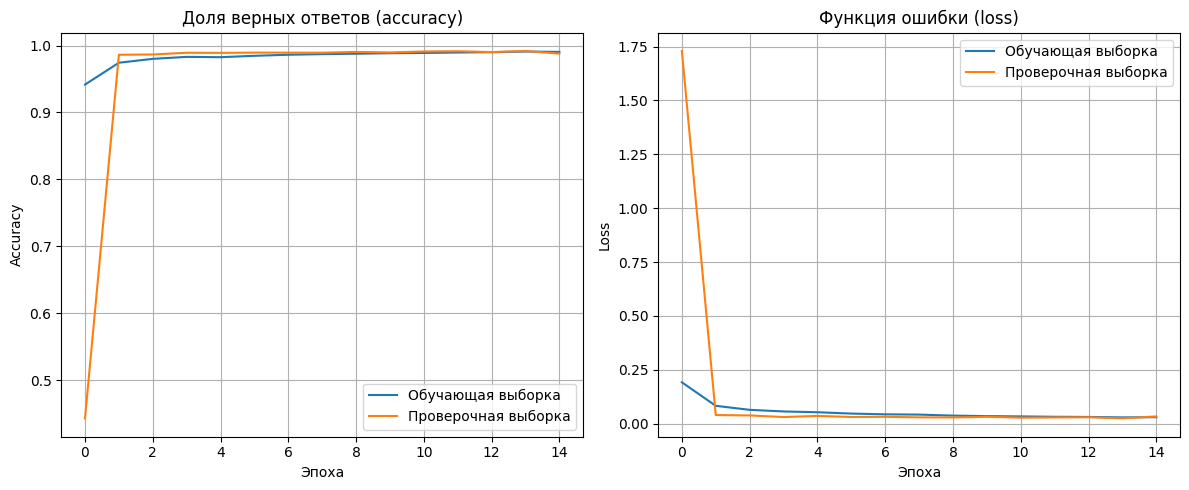

In [7]:
# ========== График обучения ==========
# Доли верных ответов на обучающей и проверочной выборках

plt.figure(figsize=(12, 5))

# График accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучающая выборка')
plt.plot(history.history['val_accuracy'], label='Проверочная выборка')
plt.title('Доля верных ответов (accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучающая выборка')
plt.plot(history.history['val_loss'], label='Проверочная выборка')
plt.title('Функция ошибки (loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Матрица ошибок (Confusion Matrix)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


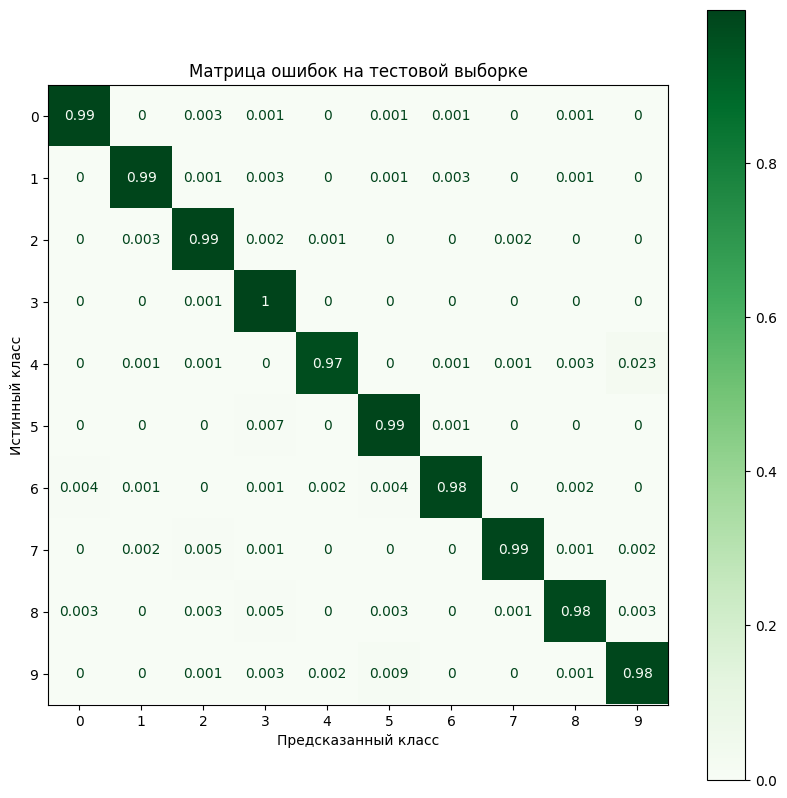


Общая точность на тестовой выборке: 0.9879 (98.79%)


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Получаем предсказания модели на тестовой выборке
y_pred = model.predict(x_test)

# Преобразуем OHE в номера классов
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Строим матрицу ошибок (нормализованную)
cm = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
cm = np.round(cm, 3)

# Отображаем матрицу ошибок
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(ax=ax, cmap='Greens', colorbar=True)
plt.title('Матрица ошибок на тестовой выборке')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# Вывод общей точности
accuracy = np.mean(y_pred_classes == y_true_classes)
print(f'\nОбщая точность на тестовой выборке: {accuracy:.4f} ({accuracy*100:.2f}%)')